In [1]:
pip install easygui

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Importing required libraries
import cv2  # for image processing
import easygui  # to open the filebox
import numpy as np  # to store image arrays
import sys
import matplotlib.pyplot as plt  # for plotting images
import os  # for OS path operations
import tkinter as tk  # for GUI
from tkinter import filedialog, Button, Label, TOP, messagebox
from PIL import ImageTk, Image  # for handling images in tkinter

In [4]:
# Function to upload an image file
def upload():
    """Opens a file dialog to select an image and calls the cartoonify function."""
    ImagePath = easygui.fileopenbox()
    if ImagePath:  # Check if a file is selected
        cartoonify(ImagePath)
    else:
        print("No file selected.")

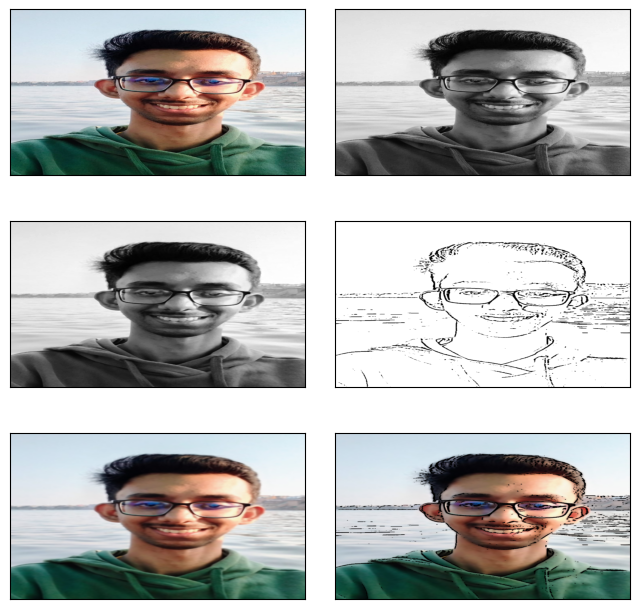

In [5]:
# Function to cartoonify the image
def cartoonify(ImagePath):
    """Applies cartoon effect to an image."""
    # Step 1: Read the image
    originalImage = cv2.imread(ImagePath)
    if originalImage is None:  # Check if the image is loaded successfully
        print("Error: Unable to load image. Please check the file path.")
        return

    originalImage = cv2.cvtColor(originalImage, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

    # Step 2: Resize the original image for display purposes
    ReSized1 = cv2.resize(originalImage, (960, 540))

    # Step 3: Convert the image to grayscale
    grayScaleImage = cv2.cvtColor(originalImage, cv2.COLOR_BGR2GRAY)
    ReSized2 = cv2.resize(grayScaleImage, (960, 540))

    # Step 4: Apply median blur to smoothen the grayscale image
    smoothGrayScale = cv2.medianBlur(grayScaleImage, 5)
    ReSized3 = cv2.resize(smoothGrayScale, (960, 540))

    # Step 5: Retrieve edges using adaptive thresholding
    getEdge = cv2.adaptiveThreshold(smoothGrayScale, 255,
                                    cv2.ADAPTIVE_THRESH_MEAN_C,
                                    cv2.THRESH_BINARY, 9, 9)
    ReSized4 = cv2.resize(getEdge, (960, 540))

    # Step 6: Apply bilateral filter to create a smooth color image
    colorImage = cv2.bilateralFilter(originalImage, 9, 300, 300)
    ReSized5 = cv2.resize(colorImage, (960, 540))

    # Step 7: Combine edges and color image using bitwise AND operation
    cartoonImage = cv2.bitwise_and(colorImage, colorImage, mask=getEdge)
    ReSized6 = cv2.resize(cartoonImage, (960, 540))

    # Step 8: Display all transformations in a single plot
    images = [ReSized1, ReSized2, ReSized3, ReSized4, ReSized5, ReSized6]
    fig, axes = plt.subplots(3, 2, figsize=(8, 8), subplot_kw={'xticks': [], 'yticks': []}, gridspec_kw=dict(hspace=0.1, wspace=0.1))
    
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i], cmap='gray')
    
    plt.show()

    # Save button functionality after cartoonification is complete
    save_button = Button(top, text="Save Cartoon Image", command=lambda: save(ReSized6, ImagePath), padx=30, pady=5)
    save_button.configure(background="#364156", foreground="white", font=('calibri', 10, 'bold'))
    save_button.pack(side=TOP, pady=50)


# Function to save the cartoonified image
def save(ReSized6, ImagePath):
    """Saves the cartoonified image."""
    newName = "cartoonified_Image"
    path1 = os.path.dirname(ImagePath)  # Get directory of original file
    extension = os.path.splitext(ImagePath)[1]  # Get file extension (e.g., .jpg or .png)
    
    path = os.path.join(path1, newName + extension)  # Create new file path
    
    # Save the cartoonified image using OpenCV's imwrite function
    cv2.imwrite(path, cv2.cvtColor(ReSized6, cv2.COLOR_RGB2BGR))
    
    I = f"Image saved by name {newName} at {path}"
    
    messagebox.showinfo(title=None, message=I)  # Show confirmation message


# Main tkinter window setup
top = tk.Tk()
top.geometry('400x400')  # Set window size
top.title('Cartoonify Your Image!')  # Set window title
top.configure(background='white')  # Set background color

# Add a label to the window
label = Label(top, background="#CDCDCD", font=('calibri', 20, 'bold'))

# Add a button to upload and cartoonify an image
upload_button = Button(top, text="Cartoonify an Image", command=upload, padx=10, pady=5)
upload_button.configure(background='#364156', foreground='white', font=('calibri',10,'bold'))
upload_button.pack(side=TOP,pady=50)

# Run the tkinter main loop
top.mainloop()
